<a href="https://colab.research.google.com/github/sahanadevira/unified-mentor-project-1/blob/main/Supply_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!ls

DataCoSupplyChainDataset.csv  sample_data


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)


In [19]:
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin1')

In [20]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (180519, 53)

Column Names:
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card 

In [21]:
df = df.drop_duplicates()

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (180519, 53)


In [22]:
total_revenue = df['Sales'].sum()

total_profit = df['Order Profit Per Order'].sum()

profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue =", total_revenue)
print("Total Profit =", total_profit)
print("Profit Margin (%) =", round(profit_margin,2))

Total Revenue = 36784735.01337984
Total Profit = 3966902.9740503575
Profit Margin (%) = 10.78


Category Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Name: Sales, dtype: float64


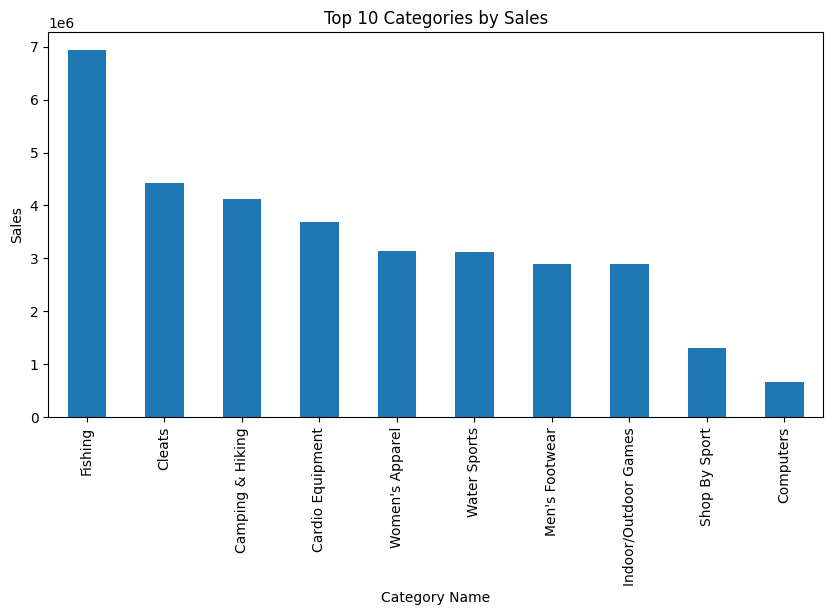

In [23]:
top_categories = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_categories)

top_categories.plot(kind='bar')

plt.title('Top 10 Categories by Sales')
plt.ylabel('Sales')
plt.show()

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Name: Order Profit Per Order, dtype: float64


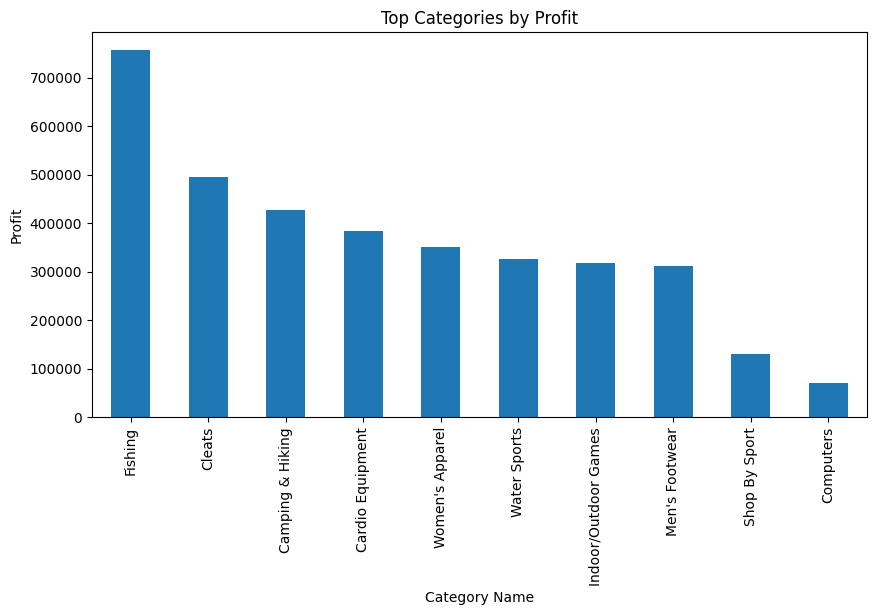

In [24]:
category_profit = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False)

print(category_profit.head(10))

category_profit.head(10).plot(kind='bar')

plt.title('Top Categories by Profit')
plt.ylabel('Profit')
plt.show()

Customer Id
2641     2441.970003
1657     2196.919992
9833     1938.390015
2626     1928.570015
5004     1917.990002
3735     1906.360009
749      1855.149989
5560     1831.460010
10967    1822.330006
5053     1813.339999
Name: Order Profit Per Order, dtype: float64


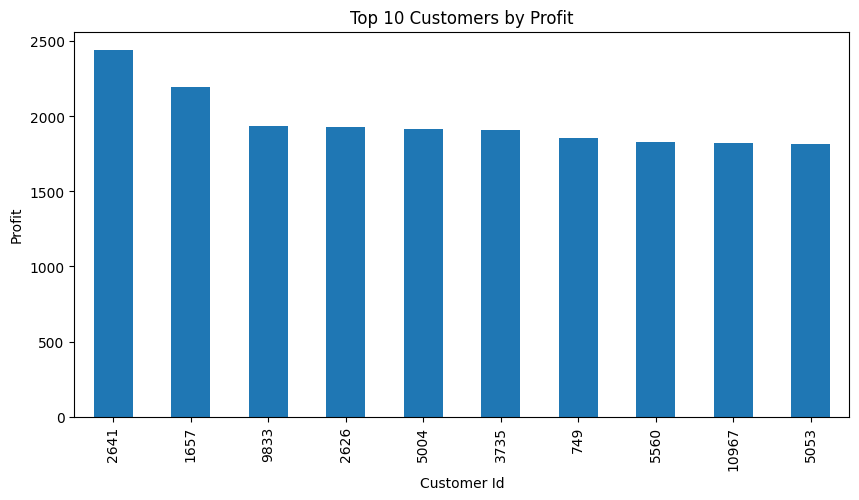

In [25]:
top_customers = df.groupby('Customer Id')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)

print(top_customers)

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Profit')
plt.ylabel('Profit')
plt.show()

                          Order Item Discount Rate  Order Item Profit Ratio
Order Item Discount Rate                  1.000000                -0.002691
Order Item Profit Ratio                  -0.002691                 1.000000


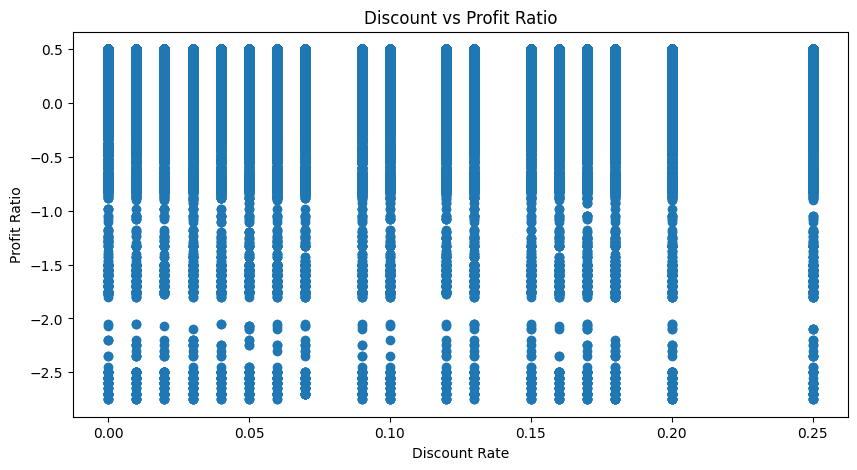

In [26]:
discount_profit = df[['Order Item Discount Rate',
                      'Order Item Profit Ratio']]

print(discount_profit.corr())

plt.scatter(
    df['Order Item Discount Rate'],
    df['Order Item Profit Ratio']
)

plt.xlabel('Discount Rate')
plt.ylabel('Profit Ratio')
plt.title('Discount vs Profit Ratio')

plt.show()

Market
Europe          1.169443e+06
LATAM           1.123322e+06
Pacific Asia    8.577534e+05
USCA            5.643138e+05
Africa          2.520712e+05
Name: Order Profit Per Order, dtype: float64


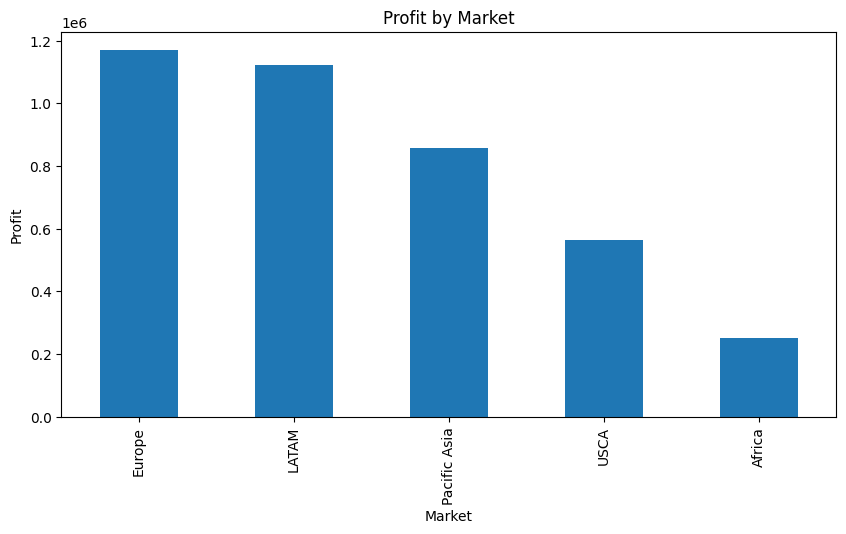

In [27]:
market_profit = df.groupby('Market')['Order Profit Per Order'].sum().sort_values(ascending=False)

print(market_profit)

market_profit.plot(kind='bar')

plt.title('Profit by Market')
plt.ylabel('Profit')

plt.show()

Order Region
Western Europe     625446.080548
Central America    616341.570651
South America      335154.400817
Northern Europe    233450.600647
Southern Europe    230829.229883
Southeast Asia     211342.819786
Oceania            201478.020484
Caribbean          171825.640024
South Asia         165703.900124
West of USA        164940.660455
Name: Order Profit Per Order, dtype: float64


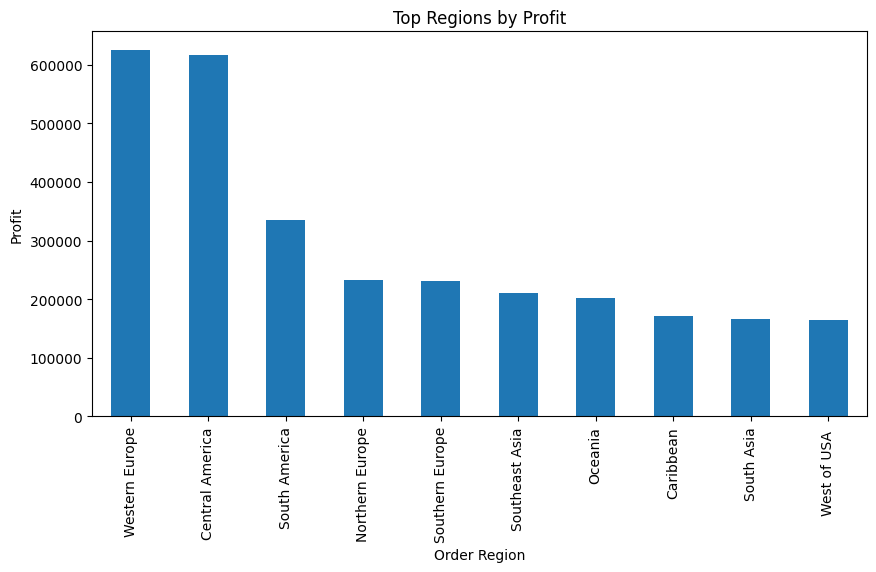

In [28]:
region_profit = df.groupby('Order Region')['Order Profit Per Order'].sum().sort_values(ascending=False)

print(region_profit.head(10))

region_profit.head(10).plot(kind='bar')

plt.title('Top Regions by Profit')
plt.ylabel('Profit')

plt.show()